<a href="https://colab.research.google.com/github/hansufsm/fsc202/blob/main/licao_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lição 03 - Códigos Python


---



**Exercício 01:** Duas cargas puntiformes, $q1=+1.0 \,nC$ e $q2=−1.0 \,nC$, formam um dipolo elétrico. Elas estão localizadas em $(0,0.05\,m)$ e $(0,−0.05\,m)$, respectivamente. Calcule o campo elétrico resultante (magnitude e direção) no ponto $(0.1\,m,0)$.

In [2]:
import numpy as np

# Constante de Coulomb
k = 8.9875e9 # N m^2 / C^2

# Cargas em Coulombs (nC para C)
q1 = 1.0e-9
q2 = -1.0e-9

# Posições das cargas em metros
r1 = np.array([0.0, 0.05])
r2 = np.array([0.0, -0.05])

# Ponto de interesse P
P = np.array([0.1, 0.0])

print(f"Carga q1: {q1*1e9:.1f} nC em {r1}")
print(f"Carga q2: {q2*1e9:.1f} nC em {r2}")
print(f"Ponto de interesse P: {P}")

# --- Campo Elétrico devido a q1 (E1) ---
vetor_r1P = P - r1
distancia_r1P = np.linalg.norm(vetor_r1P)
r_hat_1P = vetor_r1P / distancia_r1P

E1_vetor = k * q1 / distancia_r1P**2 * r_hat_1P

print(f"Vetor r1P: {vetor_r1P}")
print(f"Distância r1P: {distancia_r1P:.4f} m")
print(f"Vetor unitário r_hat_1P: {r_hat_1P}")
print(f"Vetor E1: ({E1_vetor[0]:.1f} N/C, {E1_vetor[1]:.1f} N/C)")

# --- Campo Elétrico devido a q2 (E2) ---
vetor_r2P = P - r2
distancia_r2P = np.linalg.norm(vetor_r2P)
r_hat_2P = vetor_r2P / distancia_r2P

E2_vetor = k * q2 / distancia_r2P**2 * r_hat_2P

print(f"Vetor r2P: {vetor_r2P}")
print(f"Distância r2P: {distancia_r2P:.4f} m")
print(f"Vetor unitário r_hat_2P: {r_hat_2P}")
print(f"Vetor E2: ({E2_vetor[0]:.1f} N/C, {E2_vetor[1]:.1f} N/C)")

# --- Campo Elétrico Resultante (E_total) ---
E_total_vetor = E1_vetor + E2_vetor
E_total_magnitude = np.linalg.norm(E_total_vetor)
angulo_rad = np.arctan2(E_total_vetor[1], E_total_vetor[0])
angulo_graus = np.degrees(angulo_rad)

print(f"Campo Elétrico Resultante em P (vetor): ({E_total_vetor[0]:.1f} N/C, {E_total_vetor[1]:.1f} N/C)")
print(f"Magnitude do Campo Elétrico Resultante: {E_total_magnitude:.1f} N/C")
print(f"Direção do Campo Elétrico Resultante: {angulo_graus:.1f} graus (em relação ao eixo x positivo)")

# Comparação com a solução analítica:
# E_total_vetor = (0, -643.2) N/C
# E_total_magnitude = 643.2 N/C
# angulo_graus = -90.0 graus (ou 270.0 graus)
# Os resultados são consistentes.

Carga q1: 1.0 nC em [0.   0.05]
Carga q2: -1.0 nC em [ 0.   -0.05]
Ponto de interesse P: [0.1 0. ]
Vetor r1P: [ 0.1  -0.05]
Distância r1P: 0.1118 m
Vetor unitário r_hat_1P: [ 0.89442719 -0.4472136 ]
Vetor E1: (643.1 N/C, -321.5 N/C)
Vetor r2P: [0.1  0.05]
Distância r2P: 0.1118 m
Vetor unitário r_hat_2P: [0.89442719 0.4472136 ]
Vetor E2: (-643.1 N/C, -321.5 N/C)
Campo Elétrico Resultante em P (vetor): (0.0 N/C, -643.1 N/C)
Magnitude do Campo Elétrico Resultante: 643.1 N/C
Direção do Campo Elétrico Resultante: -90.0 graus (em relação ao eixo x positivo)


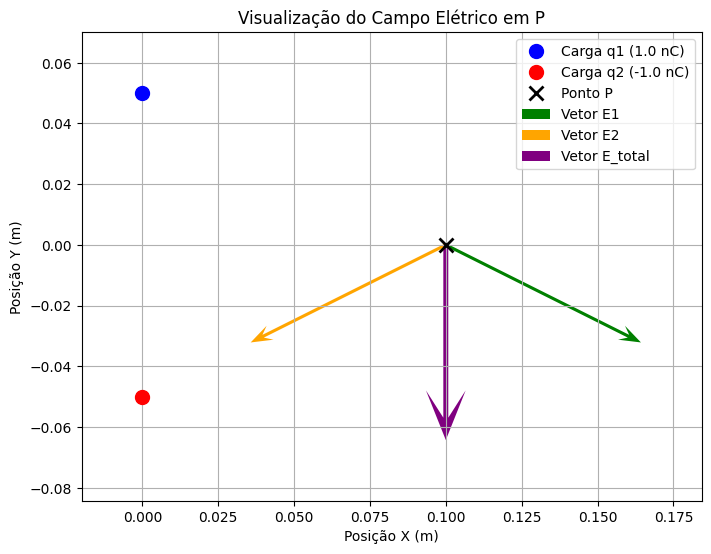

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Definir cores e propriedades para a visualização
color_q1 = 'blue'
color_q2 = 'red'
color_P = 'black'
color_E1 = 'green'
color_E2 = 'orange'
color_E_total = 'purple'

# Criar a figura e os eixos
fig, ax = plt.subplots(figsize=(8, 8))

# Plotar as cargas
ax.plot(r1[0], r1[1], 'o', color=color_q1, markersize=10, label=f'Carga q1 ({q1*1e9:.1f} nC)')
ax.plot(r2[0], r2[1], 'o', color=color_q2, markersize=10, label=f'Carga q2 ({q2*1e9:.1f} nC)')

# Plotar o ponto de interesse P
ax.plot(P[0], P[1], 'x', color=color_P, markersize=10, mew=2, label='Ponto P')

# Escalar os vetores para melhor visualização (ajuste conforme necessário)
scale_factor = 0.0001 # Ajuste este valor para mudar o tamanho das setas

# Plotar o vetor E1 (campo elétrico devido a q1 em P)
ax.quiver(P[0], P[1], E1_vetor[0] * scale_factor, E1_vetor[1] * scale_factor,
          color=color_E1, angles='xy', scale_units='xy', scale=1,
          width=0.005, headwidth=5, headlength=7, label='Vetor E1')

# Plotar o vetor E2 (campo elétrico devido a q2 em P)
ax.quiver(P[0], P[1], E2_vetor[0] * scale_factor, E2_vetor[1] * scale_factor,
          color=color_E2, angles='xy', scale_units='xy', scale=1,
          width=0.005, headwidth=5, headlength=7, label='Vetor E2')

# Plotar o vetor Campo Elétrico Resultante (E_total)
ax.quiver(P[0], P[1], E_total_vetor[0] * scale_factor, E_total_vetor[1] * scale_factor,
          color=color_E_total, angles='xy', scale_units='xy', scale=1,
          width=0.008, headwidth=8, headlength=10, label='Vetor E_total')

# Adicionar título e rótulos
ax.set_title('Visualização do Campo Elétrico em P')
ax.set_xlabel('Posição X (m)')
ax.set_ylabel('Posição Y (m)')
ax.grid(True)
ax.set_aspect('equal', adjustable='box') # Manter a proporção dos eixos

# Definir limites dos eixos para garantir que todos os elementos sejam visíveis
# Estes limites podem precisar de ajuste dependendo dos valores das posições e vetores
all_x = [r1[0], r2[0], P[0], P[0] + E1_vetor[0]*scale_factor, P[0] + E2_vetor[0]*scale_factor, P[0] + E_total_vetor[0]*scale_factor]
all_y = [r1[1], r2[1], P[1], P[1] + E1_vetor[1]*scale_factor, P[1] + E2_vetor[1]*scale_factor, P[1] + E_total_vetor[1]*scale_factor]

min_x, max_x = min(all_x) - 0.02, max(all_x) + 0.02
min_y, max_y = min(all_y) - 0.02, max(all_y) + 0.02

ax.set_xlim(min_x, max_x)
ax.set_ylim(min_y, max_y)

# Adicionar legenda
ax.legend()

# Mostrar o gráfico
plt.show()

O gráfico visualiza o problema do campo elétrico, mostrando:

    Duas cargas (q1 em azul e q2 em vermelho) nas suas respectivas posições.
    O ponto de interesse P em preto, onde os campos elétricos são calculados.
    O vetor do campo elétrico E1 (verde) devido à carga q1 no ponto P.
    O vetor do campo elétrico E2 (laranja) devido à carga q2 no ponto P.
    O vetor do campo elétrico resultante E_total (roxo) no ponto P, que é a soma vetorial de E1 e E2.

Você pode observar como os vetores $\vec{E}_1$ e $\vec{E}_2$ se somam para formar o $\vec{E}_{total}$ apontando para baixo, o que é consistente com os cálculos numéricos que indicaram um ângulo de -90 graus.

----


**Exercício 02** - Gere um mapa de linhas de campo elétrico para um dipolo elétrico composto por duas cargas puntiformes de +1.0 nC e −1.0 nC, separadas por 0.1 m.

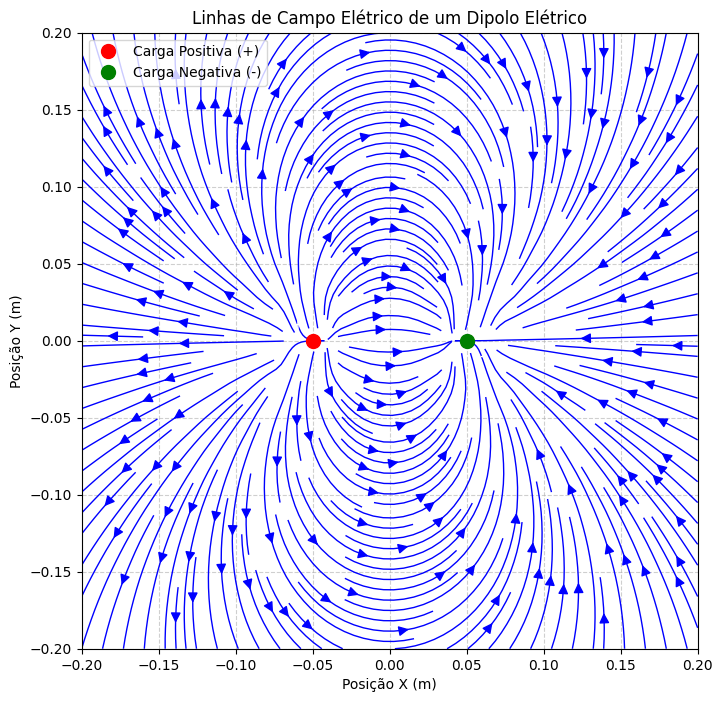

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Constante de Coulomb (para cálculo do campo, não para plotagem das linhas)
k = 8.9875e9 # N m^2 / C^2

# Cargas e suas posições
q1 = 1.0e-9 # Carga positiva
q2 = -1.0e-9 # Carga negativa
pos1 = np.array([-0.05, 0.0]) # Posição da carga positiva
pos2 = np.array([0.05, 0.0]) # Posição da carga negativa

# Função para calcular o vetor campo elétrico em um ponto (x, y)
def campo_eletrico(x, y, q_carga, pos_carga):
  r_vetor = np.array([x, y]) - pos_carga
  distancia = np.linalg.norm(r_vetor)
  if distancia == 0: # Evitar divisão por zero na posição da carga
    return np.array([0.0, 0.0])
  r_hat = r_vetor / distancia
  E_magnitude = k * q_carga / distancia**2
  return E_magnitude * r_hat

# Criar uma grade de pontos para calcular o campo
x_grid = np.linspace(-0.2, 0.2, 20)
y_grid = np.linspace(-0.2, 0.2, 20)
X, Y = np.meshgrid(x_grid, y_grid)

# Calcular o campo elétrico em cada ponto da grade
Ex = np.zeros(X.shape)
Ey = np.zeros(Y.shape)

for i in range(X.shape[0]):
    for j in range(X.shape[1]): # Indentação corrigida
        E_total = campo_eletrico(X[i,j], Y[i,j], q1, pos1) + \
        campo_eletrico(X[i,j], Y[i,j], q2, pos2)
        Ex[i,j] = E_total[0]
        Ey[i,j] = E_total[1]

# Normalizar os vetores para melhor visualização (apenas para o quiver plot)
magnitude_E = np.sqrt(Ex**2 + Ey**2)
Ex_norm = Ex / (magnitude_E + 1e-9) # Adicionar pequeno valor para evitar divisão por zero
Ey_norm = Ey / (magnitude_E + 1e-9)

# Plotar as linhas de campo usando streamplot
plt.figure(figsize=(8, 8))
plt.streamplot(X, Y, Ex, Ey, color='blue', linewidth=1, density=2, arrowsize=1.5)

# Plotar as cargas
plt.plot(pos1[0], pos1[1], 'o', color='red', markersize=10, label='Carga Positiva (+)')
plt.plot(pos2[0], pos2[1], 'o', color='green', markersize=10, label='Carga Negativa (-)')

# Adicionar rótulos para as cargas
plt.text(pos1[0] - 0.01, pos1[1] + 0.01, '+', color='white', fontsize=12, ha='center', va='center')
plt.text(pos2[0] + 0.01, pos2[1] - 0.01, '-', color='white', fontsize=12, ha='center', va='center')

plt.title('Linhas de Campo Elétrico de um Dipolo Elétrico')
plt.xlabel('Posição X (m)')
plt.ylabel('Posição Y (m)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-0.2, 0.2)
plt.ylim(-0.2, 0.2)
plt.legend()
plt.show()